<img src= "./images/ml_loan_banner.jpg" width = "800">
</img>


<h2 style= "color: #F4C300; text-align: left; font-weight: bold;">
Loan Approval and Credit Risk Assessment
</h2>

<h3 style= "color: #F4C300; text-align: left; font-weight: bold;">
Project Overview
</h3>

This project develops a machine learning classification model to support loan approval decisions using historical applicant, financial, and credit data from 20,000 past loan applications. The analysis follows the CRISP-DM framework, progressing from understanding the business problem and exploring the data to preprocessing, model development, and evaluation.

<h3 style= "color: #F4C300;; text-align: left; font-weight: bold;">
1. Business Understanding
</h3>

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
1.1. Business Context
</h4>
FinTech Innovations partners with traditional banks to improve their loan approval processes. The current process relies heavily on manual review by loan officers, which can result in slower application processing and inconsistent lending decisions. The goal of this project is to develop a machine learning solution that uses historical applicant information to support faster, more consistent, and data-driven loan approval decisions while maintaining appropriate oversight.

The key stakeholders include loan applicants, who need timely and fair decisions; loan officers, who need reliable information to support their assessments; risk management teams, who need to minimize exposure to high-risk lending; and FinTech Innovations and its banking partners, who need an efficient and financially sustainable approval process.

Incorrect predictions have different financial consequences. A false positive, where the model recommends approval for a loan that should not be approved and subsequently defaults, has an estimated average cost of $50,000. A false negative, where the model rejects a creditworthy applicant, represents approximately $8,000 in lost potential profit. Therefore, false approvals are considerably more costly to the business than false denials, although both errors need to be considered when evaluating the model.

This project will use a classification approach, with LoanApproved as the target variable, where 1 represents an approved loan and 0 represents a denied loan. Classification is appropriate because the objective is to predict one of two possible loan approval outcomes rather than a continuous numerical value. The dataset also contains a RiskScore variable, but the primary objective of this analysis will be predicting the historical loan approval decision.


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
1.2. Modeling Goals and Success Criteria
</h4>
The primary modeling goal is to develop a classification model that can distinguish between approved and denied loan applications while accounting for the unequal financial consequences of prediction errors. Precision, recall, F1-score, and ROC-AUC will be evaluated rather than relying on accuracy alone. Precision is particularly important because false approvals carry a high financial cost, while recall is also important because rejecting creditworthy applicants results in lost business opportunities. F1-score will help assess the balance between precision and recall, while ROC-AUC will measure the model's ability to distinguish between the two classes across different classification thresholds.

In addition to standard classification metrics, a custom business-cost metric will be used to translate prediction errors into their estimated financial impact. Based on the business assumptions provided, the estimated cost will be calculated as ($50,000 × false positives) + ($8,000 × false negatives). This will allow models with similar statistical performance to be compared based on their potential financial consequences.

A baseline model will also be established before developing more advanced models. Because the dataset contains an imbalanced target, a simple majority-class classifier will provide a reference point for evaluating whether the machine learning models offer meaningful improvement. The final model should outperform this baseline on relevant classification metrics and should reduce the estimated business cost of incorrect decisions. Model interpretability will also be considered because loan approval decisions need to be understandable to business and risk stakeholders.

<h3 style= "color: #F4C300;; text-align: left; font-weight: bold;">
2. Data Understanding
</h3>

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.1. Dataset Overview
</h4>

This section explores the loan application dataset to understand its structure, feature types, distributions, relationships, and potential data quality issues. The analysis further examines the distribution of the `LoanApproved` target variable and identifies features that may require cleaning, transformation or further investigation before model development.

In [1]:
# Import of required modules

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

In [5]:
# Loading in the data
df = pd.read_csv("financial_loan_data.csv")

# view the first few rows
df.head()


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [7]:
df.shape

(20000, 35)

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>

The dataset contains **20,000 loan applications and 35 features**, with each row representing an individual loan application. The columns contain demographic, financial, credit, employment, and loan-related information, together with the `LoanApproved` target variable.

In [8]:
# now we inspect the columns names
df.columns.tolist()

['Age',
 'AnnualIncome',
 'CreditScore',
 'EmploymentStatus',
 'EducationLevel',
 'Experience',
 'LoanAmount',
 'LoanDuration',
 'MaritalStatus',
 'NumberOfDependents',
 'HomeOwnershipStatus',
 'MonthlyDebtPayments',
 'CreditCardUtilizationRate',
 'NumberOfOpenCreditLines',
 'NumberOfCreditInquiries',
 'DebtToIncomeRatio',
 'BankruptcyHistory',
 'LoanPurpose',
 'PreviousLoanDefaults',
 'PaymentHistory',
 'LengthOfCreditHistory',
 'SavingsAccountBalance',
 'CheckingAccountBalance',
 'TotalAssets',
 'TotalLiabilities',
 'MonthlyIncome',
 'UtilityBillsPaymentHistory',
 'JobTenure',
 'NetWorth',
 'BaseInterestRate',
 'InterestRate',
 'MonthlyLoanPayment',
 'TotalDebtToIncomeRatio',
 'LoanApproved',
 'RiskScore']

In [9]:
# we then inspect the data types and non null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.2. Feature Types
</h4>

In [10]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Number of numerical features: {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features)}")

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 28
Number of categorical features: 7

Numerical features:
['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']

Categorical features:
['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>

Most features are stored using data types that are consistent with their expected meaning. However, `AnnualIncome` is stored as an `object` rather than a numerical variable because its values contain currency formatting such as dollar signs and commas. This feature will require conversion to a numerical data type during data preparation.

Some integer variables, such as `LoanApproved` and `PreviousLoanDefaults`, may represent categorical or binary information rather than continuous numerical measurements. Therefore, pandas data types alone will not be used to determine how each feature is treated during preprocessing.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.3. Descriptive Statistics
</h4>


In [11]:
# Summary statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00


In [12]:
# Summary statistics for categorical features
df.describe(include="object").T

,count,unique,top,freq
AnnualIncome,20000,17516,"$15,000.00",584
EmploymentStatus,20000,3,Employed,17036
EducationLevel,19099,5,Bachelor,5804
MaritalStatus,18669,4,Married,9370
HomeOwnershipStatus,20000,4,Mortgage,7939
BankruptcyHistory,20000,2,No,18952
LoanPurpose,20000,5,Home,5925


In [13]:
# Number of unique values in each column
df.nunique().sort_values()

PreviousLoanDefaults              2
LoanApproved                      2
BankruptcyHistory                 2
EmploymentStatus                  3
MaritalStatus                     4
HomeOwnershipStatus               4
LoanPurpose                       5
EducationLevel                    5
NumberOfDependents                6
NumberOfCreditInquiries           8
LoanDuration                     10
NumberOfOpenCreditLines          14
JobTenure                        17
LengthOfCreditHistory            29
PaymentHistory                   38
Experience                       62
Age                              63
RiskScore                        73
CreditScore                     322
MonthlyDebtPayments            1299
CheckingAccountBalance         5151
SavingsAccountBalance          9054
LoanAmount                    15578
TotalLiabilities              17163
MonthlyIncome                 17489
AnnualIncome                  17516
NetWorth                      17724
BaseInterestRate            

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.4. Data Quality Assessment
</h4>


In [14]:
# Count missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

MaritalStatus            1331
EducationLevel            901
SavingsAccountBalance     572
dtype: int64

In [15]:
# percentage of missing values
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

MaritalStatus            6.655
EducationLevel           4.505
SavingsAccountBalance    2.860
dtype: float64


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>

Missing values are present in `MaritalStatus`, `EducationLevel`, and `SavingsAccountBalance`. The proportion of missing data is relatively small, but the appropriate treatment may differ by feature. The categorical variables `MaritalStatus` and `EducationLevel` may require categorical imputation, while `SavingsAccountBalance` is numerical and may require a numerical imputation strategy.

The missing values will not be removed at this stage because doing so without understanding their patterns could unnecessarily discard useful observations or introduce bias. Appropriate imputation strategies will be considered during data preparation.

In [16]:
# Check for duplicate observations
df.duplicated().sum()

0

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>

No fully duplicated rows were identified in the dataset, it meand that its not an immediate problem we have

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.5. Target Variable Analysis
</h4>

In [19]:
# Target class counts
df["LoanApproved"].value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

In [20]:
# Target class proportions
df["LoanApproved"].value_counts(normalize=True) * 100

LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64

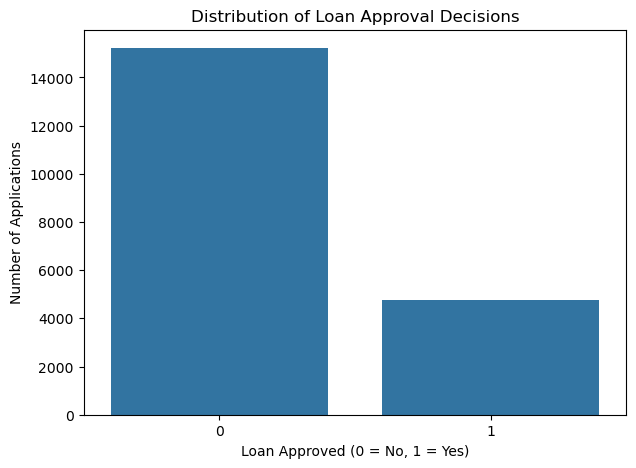

In [21]:
# Visualization

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="LoanApproved")

plt.title("Distribution of Loan Approval Decisions")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Number of Applications")

plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.6. Feature Categories
</h4>

For preprocessing purposes, the features can broadly be categorized as follows:

- **Numerical features:** Variables representing measurable quantities, including `Age`, `CreditScore`, `Experience`, `LoanAmount`, `MonthlyDebtPayments`, `CreditCardUtilizationRate`, `DebtToIncomeRatio`, `SavingsAccountBalance`, `CheckingAccountBalance`, `TotalAssets`, `TotalLiabilities`, `MonthlyIncome`, `NetWorth`, and related financial measures.

- **Categorical features:** Variables representing groups or labels, including `EmploymentStatus`, `MaritalStatus`, `HomeOwnershipStatus`, `BankruptcyHistory`, and `LoanPurpose`.

- **Ordinal features:** `EducationLevel` may contain categories with a meaningful educational progression and will be investigated to determine whether ordinal encoding is appropriate.

- **Discrete features:** Variables such as `PreviousLoanDefaults` and `LoanApproved` represent discrete outcomes rather than continuous measurements.

Some variables require additional investigation before final preprocessing decisions are made. In particular, `AnnualIncome` should be numerical but is currently stored as text because of currency formatting.

In [22]:
df["EducationLevel"].value_counts(dropna=False)

EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
NaN             901
Name: count, dtype: int64

In [23]:
for column in categorical_features:
    print(f"\n{column}")
    print("-" * 40)
    print(df[column].value_counts(dropna=False))


AnnualIncome
----------------------------------------
AnnualIncome
$15,000.00     584
$300,000.00     26
$68,064.00       4
$24,627.00       4
$36,604.00       4
              ... 
$48,316.00       1
$50,463.00       1
$25,001.00       1
$22,593.00       1
$53,227.00       1
Name: count, Length: 17516, dtype: int64

EmploymentStatus
----------------------------------------
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel
----------------------------------------
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
NaN             901
Name: count, dtype: int64

MaritalStatus
----------------------------------------
MaritalStatus
Married     9370
Single      5665
Divorced    2704
NaN         1331
Widowed      930
Name: count, dtype: int64

HomeOwnershipStatus
----------------------------------------
HomeOwnershipStatus
Mortgage    7939
Rent        6

## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [ ]:
# Imports
None

In [ ]:
# EDA Code Here - Create New Cells As Needed
None

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [ ]:
# Data Prep Code Here - Create New Cells As Needed
None

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [ ]:
#  Modeling Code Here - Create New Cells as Needed
None

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements